# Cosmic Evolution with Time-Based Parametrization (`cEvolution`)

This notebook demonstrates the new `cEvolution` class, a revolutionary approach to evolving discrete massive black hole binary (MBHB) populations from cosmological simulations.

## Key Innovation: Time as the Free Parameter

Traditional binary evolution models in `holodeck` use **semi-major axis** as the primary evolutionary parameter, 
tracking binaries as they shrink from kiloparsec to sub-parsec separations. The new `cEvolution` class instead uses
 **cosmic time** as the free parameter. The main reason for this change is that it allows the use of the new 
 cbd-driven evolution module, which, at times, can lead to **positive** valued $\dot{a}_{\rm b}$ values. 

This notebook showcases initialization, evolution and analysis of binaries with this new class.

# 1. Initialization of population, hardening and accretion models

In [1]:
import holodeck as holo
import numpy as np
from holodeck.discrete import population
from holodeck import accretion

ECCEN_INIT = 0.01
F_EDD = 0.1
NSTEPS = 100
select=10 #can be None, if all binaries are to be evolved.

pop = population.Pop_Illustris(select=select)
size = pop.size
eccen = np.ones(size) * ECCEN_INIT
pop = population.Pop_Illustris(eccen=eccen, select=select)

hards = [
    holo.hardening.Hard_GW,
    holo.hardening.CBD_Torques(allow_softening=True),
    holo.hardening.Sesana_Scattering(),
    holo.hardening.Dynamical_Friction_NFW(attenuate=True),
]

acc = accretion.Accretion(
    accmod='Siwek22', f_edd=F_EDD, subpc=True, evol_mass=False, edd_lim=1.0,
)


=====
WARNING SELECTING ONLY 10 BINARIES FROM DATA
=====


=====
WARNING SELECTING ONLY 10 BINARIES FROM DATA
=====



/Users/pranavsatheesh/mbhb_evolution/holodeck/holodeck/host_relations.py:1498: RuntimeWarning: overflow encountered in exp
  t3 = 1 + np.exp(10.0 ** -xx)


# 2. Evolving the binaries

In [2]:
from holodeck.discrete import evolution as evo

evo_acc = evo.cEvolution(pop, hards, acc=acc)
evo_acc.evolve()

  0%|          | 0/10 [00:00<?, ?it/s]

/Users/pranavsatheesh/mbhb_evolution/holodeck/holodeck/discrete/evolution.py:1471: RuntimeWarning: divide by zero encountered in divide
  dt_mdot = CFL * np.min(self.mass[step, :] / mdot)


# 3. Analysis of binaries

## Structure and Architecture of `cEvolution`

Based on the evolved binary data, we can understand the key structural elements of the `cEvolution` class:

### **Data Organization**
The `cEvolution` object stores evolutionary history as **time-ordered arrays**:

- **`evo.mass[f_ind:l_ind]`**: Binary component masses `[M₁, M₂]` in grams, shape `(N_steps, 2)`
- **`evo.tlook[f_ind:l_ind]`**: Lookback time coordinates in seconds  
- **`evo.sepa[f_ind:l_ind]`**: Semi-major axis evolution in cm
- **`evo.eccen[f_ind:l_ind]`**: Eccentricity evolution (dimensionless)

### **Binary Indexing System**  
The `cEvolution` class uses a sophisticated indexing scheme:

- **`evo._last_index`**: Array of end indices for each binary's evolutionary track
- **Slicing pattern**: `f_ind:l_ind` extracts the complete evolution of individual binaries
- Each binary gets its own contiguous segment in the arrays

### **Time-Centric Evolution**
Unlike the previous method using semi-major axis steps, `cEvolution` advances in **cosmic time**:

- **Formation time reference**: `t_formation = t[0] - t[:]` gives time since binary formation
- **Sub-parsec filtering**: `ind_subpc = sepa <= 1*PC` identifies the gravitationally-bound regime


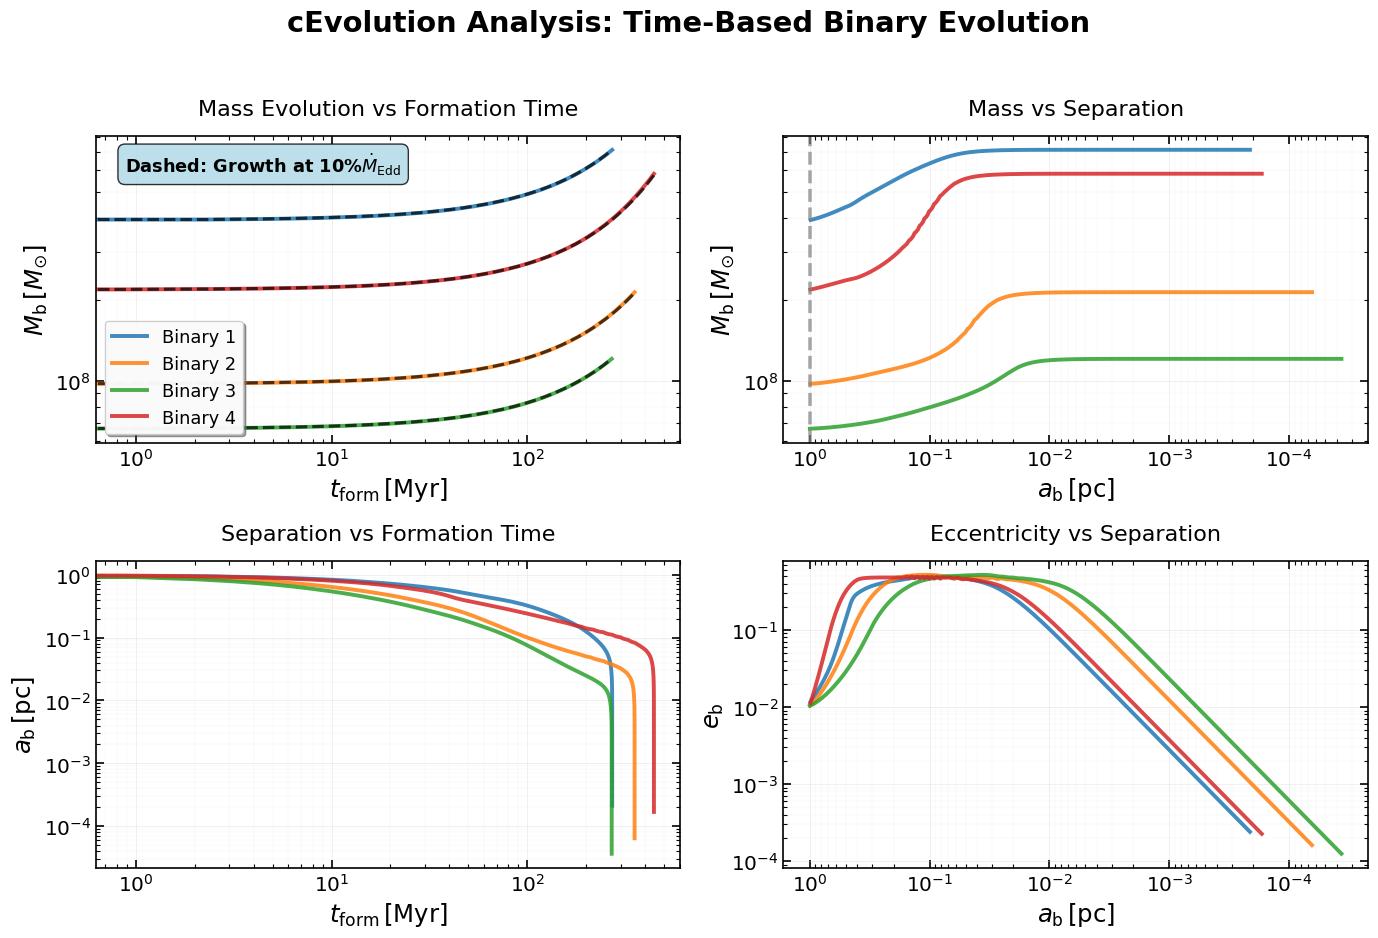

In [4]:
evo = evo_acc

import matplotlib.pyplot as plt
#import seaborn as sns
from holodeck.constants import MSOL, MYR, PC

# Set clean plotting style
plt.rcParams.update({
    'font.size': 14,
    'axes.linewidth': 1.2,
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'grid.linewidth': 0.5,
    'lines.linewidth': 2.5,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white'
})

# Plotting parameters  
fs = 16
lw = 2.8
figwidth = 14
figheight = 10
alpha_lines = 0.85
alpha_pred = 0.7

# Create clean figure
fig, axes = plt.subplots(2, 2, figsize=(figwidth, figheight))
fig.suptitle('cEvolution Analysis: Time-Based Binary Evolution', 
             fontsize=fs*1.3, fontweight='bold', y=0.96)

axes = axes.flatten()
f_ind = 0
j = 0

# Use distinct colors
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

for l_ind in evo._last_index:
    m1 = evo.mass[f_ind:l_ind].T[0]
    m2 = evo.mass[f_ind:l_ind].T[1]
    t = evo.tlook[f_ind:l_ind]
    sepa = evo.sepa[f_ind:l_ind]
    mtot = (m1 + m2) / MSOL
    eccen = evo.eccen[f_ind:l_ind]
    ind_subpc = evo.sepa[f_ind:l_ind] <= 1 * PC
    
    if len(mtot[ind_subpc]) > 1:
        color = colors[j % len(colors)]
        t_formation = t[ind_subpc][0] - t[ind_subpc]
        
        # Binary mass evolution vs formation time
        axes[0].loglog(t_formation/MYR, mtot[ind_subpc], 
                      color=color, alpha=alpha_lines, linewidth=lw, 
                      label=f'Binary {j+1}' if j < 6 else '')
        
        # Predicted mass growth with F_EDD factor
        m0 = mtot[ind_subpc][0]
        m_evol = [m0 * MSOL]
        for dt in np.diff(t_formation):
            mdot = acc.mdot_eddington(m_evol[-1], eps=F_EDD)  # Use F_EDD here
            dm = mdot * dt
            m_evol.append(m_evol[-1] + dm)
        m_evol = np.array(m_evol) / MSOL
        
        axes[0].loglog(t_formation/MYR, m_evol, '--', 
                      color='black', alpha=alpha_pred, linewidth=lw*0.8)
        
        # Binary mass vs separation
        axes[1].loglog(sepa[ind_subpc]/PC, mtot[ind_subpc], 
                      color=color, alpha=alpha_lines, linewidth=lw)
        
        # Separation vs formation time
        axes[2].loglog(t_formation/MYR, sepa[ind_subpc]/PC, 
                      color=color, alpha=alpha_lines, linewidth=lw)
        
        # Eccentricity vs separation
        axes[3].loglog(sepa[ind_subpc]/PC, eccen[ind_subpc], 
                      color=color, alpha=alpha_lines, linewidth=lw)
        j += 1
    f_ind = l_ind + 1

# Clean styling for all axes
for i, ax in enumerate(axes):
    ax.tick_params(axis='both', which='major', labelsize=fs*0.9, 
                   width=1.2, length=6, direction='in', top=True, right=True)
    ax.tick_params(axis='both', which='minor', 
                   width=0.8, length=3, direction='in', top=True, right=True)
    
    # Subtle grid
    ax.grid(True, which='major', color='lightgray', linestyle='-', 
            linewidth=0.6, alpha=0.4)
    ax.grid(True, which='minor', color='lightgray', linestyle='-', 
            linewidth=0.3, alpha=0.25)
    
    # Invert x-axis for semi-major axis plots (large to small, left to right)
    if i in [1, 3]:  # Mass vs Separation, Eccentricity vs Separation
        ax.invert_xaxis()

# Enhanced labels and titles
axes[0].set_ylabel(r'$M_{\rm b} \, [M_{\odot}]$', fontsize=fs*1.1, fontweight='bold')
axes[0].set_xlabel(r'$t_{\rm form} \, [\rm{Myr}]$', fontsize=fs*1.1, fontweight='bold')
axes[0].set_title('Mass Evolution vs Formation Time', fontsize=fs, pad=15)

axes[1].set_xlabel(r'$a_{\rm b} \, [\rm{pc}]$', fontsize=fs*1.1, fontweight='bold')
axes[1].set_ylabel(r'$M_{\rm b} \, [M_{\odot}]$', fontsize=fs*1.1, fontweight='bold')
axes[1].set_title('Mass vs Separation', fontsize=fs, pad=15)
axes[1].axvline(x=1, linestyle='--', alpha=0.7, linewidth=lw*0.9, color='gray')

axes[2].set_xlabel(r'$t_{\rm form} \, [\rm{Myr}]$', fontsize=fs*1.1, fontweight='bold')
axes[2].set_ylabel(r'$a_{\rm b} \, [\rm{pc}]$', fontsize=fs*1.1, fontweight='bold')
axes[2].set_title('Separation vs Formation Time', fontsize=fs, pad=15)

axes[3].set_xlabel(r'$a_{\rm b} \, [\rm{pc}]$', fontsize=fs*1.1, fontweight='bold')
axes[3].set_ylabel(r'$e_{\rm b}$', fontsize=fs*1.1, fontweight='bold')
axes[3].set_title('Eccentricity vs Separation', fontsize=fs, pad=15)

# Add legend with better positioning
if j > 0:
    axes[0].legend(loc='lower left', fontsize=fs*0.8, framealpha=0.95, 
                   fancybox=True, shadow=True)

# Updated annotation for F_EDD factor
axes[0].text(0.05, 0.95, f'Dashed: Growth at {F_EDD:.0%}' + r'$\dot{M}_{\rm Edd}$', 
             transform=axes[0].transAxes, fontsize=fs*0.8, 
             bbox=dict(boxstyle='round,pad=0.4', facecolor='lightblue', alpha=0.8),
             verticalalignment='top', fontweight='bold')

# Tight layout with proper spacing
plt.tight_layout(rect=[0, 0.02, 1, 0.94])
plt.show()